## Setup & Configuration

In [19]:
# Experiment Setup
import sys
sys.path.insert(0, '..')

from src.config.ConfigManager import ConfigManager
from src.ocr import run_ocr, run_title_ocr, run_name_ocr, preprocess_image
from src.utils import extract_quest_areas, extract_echoes_areas
from src.wiki import get_best_wiki_url, fetch_quest_stages, get_best_match
from src.tts import get_tts_backend
from src.db import NPCDatabase

# Configuration
DEVICE = "cpu"  # Change to "gpu" for OmniVoice
cfg = ConfigManager()
print(f"✅ Loaded config from: {cfg.config_path}")
print(f"   Tesseract: {cfg.tesseract_cmd}")
print(f"   Device: {DEVICE}")

✅ Loaded config from: C:\Users\admin\.khazad-voice-tts\config.ini
   Tesseract: C:\Users\admin\AppData\Local\Programs\Tesseract-OCR\tesseract.exe
   Device: cpu


## Load & Display Screenshot

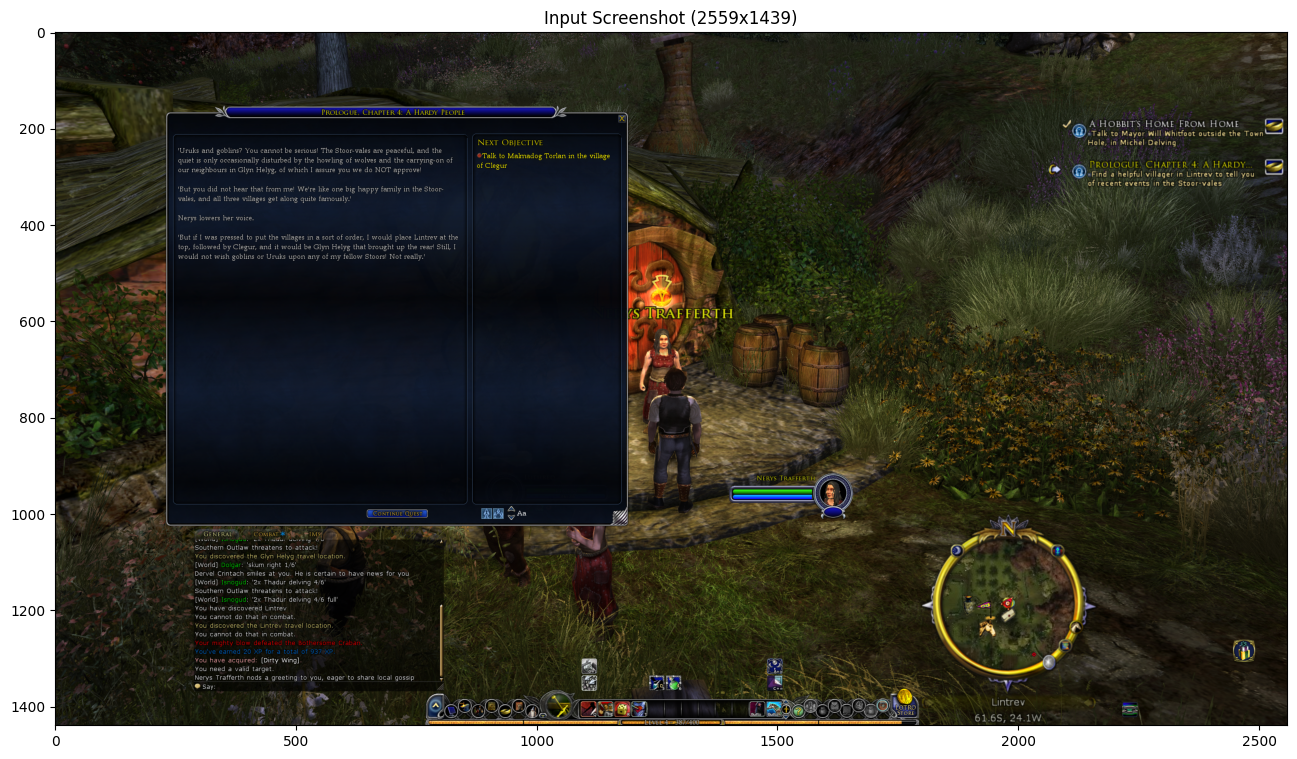

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

# --- CHANGE THIS PATH ---
SCREENSHOT_PATH = "test_screenshots/Screenshot 2025-08-11 210155.png"

img = Image.open(SCREENSHOT_PATH)
import numpy as np
import cv2
img_np = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.imshow(img)
ax.set_title(f"Input Screenshot ({img.size[0]}x{img.size[1]})")
plt.show()

## Quest Window Detection (Retail)

10:51:12 - [UTILS] - INFO - 📐 No layout file for retail — using scaled default offsets: {'CORNER_OFFSET_X': 11, 'CORNER_OFFSET_Y': 10, 'PADDING_INTERSECT_X': -10, 'PADDING_ICON_Y': 17}


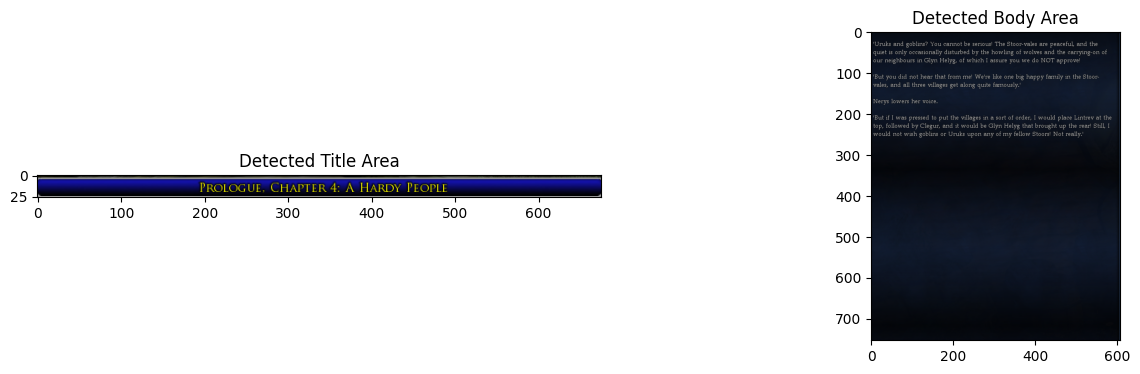

In [27]:
# Run retail auto-detection
title_pil, body_pil = extract_quest_areas(img_np)

if title_pil is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    axes[0].imshow(title_pil)
    axes[0].set_title("Detected Title Area")
    axes[1].imshow(body_pil)
    axes[1].set_title("Detected Body Area")
    plt.show()
else:
    print("❌ No quest window detected. Check templates/calibration.")

## OCR Analysis

📝 OCR Output (9 sentences):
  [0] 'Uruks and goblins?
  [1] You cannot be serious!
  [2] The Stoor-vales are peaceful, and the quiet is only occasionally disturbed by the howling of wolves and the carrying-on of our neighbours in Glyn Helyg, of which I assure you we do NOT approve!
  [3] 'But you did not hear that from me!
  [4] We're like one big happy family in the Stoor- vales, and all three villages get along quite famously.'
  [5] Nerys lowers her voice.
  [6] 'But if ] was pressed to put the villages in a sort of order, I would place Lintrev at the top, followed by Clegur, and it would be Glyn Helyg that brought up the rear!
  [7] Still, I would not wish goblins or Uruks upon any of my fellow Stoors!
  [8] Not really.'


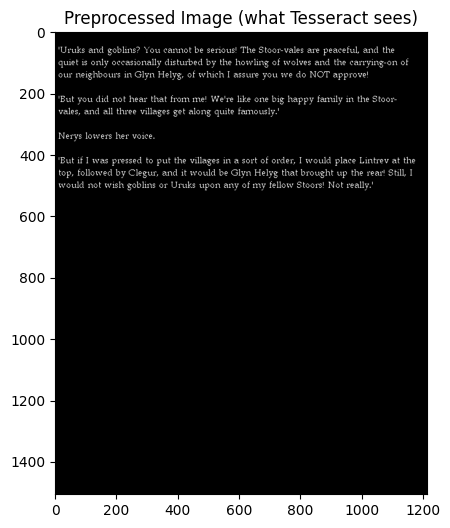

In [28]:
# Run OCR on body text
if body_pil is not None:
    sentences = run_ocr(body_pil)
    print(f"📝 OCR Output ({len(sentences)} sentences):")
    for i, s in enumerate(sentences):
        print(f"  [{i}] {s}")
    
    # Show preprocessed image
    import cv2
    thresh = preprocess_image(body_pil)
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    ax.imshow(thresh, cmap='gray')
    ax.set_title("Preprocessed Image (what Tesseract sees)")
    plt.show()

## Title OCR & Wiki Lookup

In [29]:
if title_pil is not None:
    quest_title = run_title_ocr(title_pil)
    print(f"📜 Quest Title: '{quest_title}'")
    
    # Wiki lookup
    wiki_url = get_best_wiki_url(quest_title)
    print(f"🌐 Wiki URL: {wiki_url}")
    
    stages = fetch_quest_stages(wiki_url)
    print(f"\n📖 Found {len(stages)} stages:")
    for name, text in stages.items():
        print(f"  [{name}]: {text[:100]}...")

📜 Quest Title: 'PROLOGUE, CHAPTER 4: A HARDY PEOPLE'
🌐 Wiki URL: https://lotro-wiki.com/wiki/Quest:Prologue,_Chapter_4:_A_Hardy_People

📖 Found 0 stages:


## OCR vs Wiki Alignment

In [30]:
if body_pil is not None and stages:
    ocr_text = " ".join(run_ocr(body_pil))
    best_stage, matched_text, accuracy = get_best_match(ocr_text, stages)
    
    print(f"🎯 Best Match: {best_stage} ({accuracy:.1f}%)")
    print(f"\n--- Matched Text ---")
    print(matched_text[:500])
    
    if accuracy >= 50.0:
        print(f"\n✅ Wiki text will be used (accuracy >= 50%)")
    else:
        print(f"\n⚠️ OCR text will be used (wiki accuracy too low)")

## TTS Generation

In [31]:
import numpy as np
import sounddevice as sd
import ipywidgets as widgets
from IPython.display import display

# Initialize TTS backend
tts = get_tts_backend(device_choice=DEVICE)
print(f"🔊 TTS Backend: {tts.backend_id}")

# Pick a voice and generate
voice_id, category = tts.pick_voice("Female", "Hobbit")
print(f"🎭 Voice: {voice_id} (category: {category})")

if sentences:
    print(f"⏳ Generating audio for {len(sentences)} sentences...")
    
    # Generate all sentences and combine them into one audio array
    audio_chunks = []
    for i, sentence in enumerate(sentences):
        print(sentence)
        chunk = tts.generate(sentence, voice_id)
        audio_chunks.append(chunk)
    
    # Concatenate all generated audio pieces
    full_audio = np.concatenate(audio_chunks)
    total_duration = len(full_audio) / tts.samplerate
    print(f"🎙️ Generation complete! {len(full_audio)} samples ({total_duration:.2f}s)")
    
    # --- UI Controls ---
    volume_slider = widgets.FloatSlider(
        value=0.5,          # Default 50%
        min=0.0, 
        max=1.0, 
        step=0.05,
        description='Volume:',
        readout_format='.0%'
    )
    
    play_button = widgets.Button(description="▶️ Play", button_style='success')
    stop_button = widgets.Button(description="⏹️ Stop", button_style='danger')

    def play_audio(b):
        sd.stop()  # Stop any currently playing audio first
        # Apply the current volume slider value to the audio array
        adjusted_audio = full_audio * volume_slider.value
        sd.play(adjusted_audio, tts.samplerate)
        
    def stop_audio(b):
        sd.stop()

    play_button.on_click(play_audio)
    stop_button.on_click(stop_audio)
    
    # Display the interactive controls
    display(widgets.HBox([volume_slider, play_button, stop_button]))

10:51:25 - [TTS_FACTORY] - INFO - 🐢 User selected CPU (Kokoro). Initializing...
10:51:25 - [src.tts.kokoro] - INFO - Loading Kokoro Voice Model...
C:\Users\admin\Khazad-Voice-TTS\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


C:\Users\admin\Khazad-Voice-TTS\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
10:51:26 - [src.tts.kokoro] - INFO - ✅ Voice Model Ready (CPU Mode).


🔊 TTS Backend: kokoro
🎭 Voice: bf_lily (category: hobbit female)
⏳ Generating audio for 9 sentences...
'Uruks and goblins?
You cannot be serious!
The Stoor-vales are peaceful, and the quiet is only occasionally disturbed by the howling of wolves and the carrying-on of our neighbours in Glyn Helyg, of which I assure you we do NOT approve!
'But you did not hear that from me!
We're like one big happy family in the Stoor- vales, and all three villages get along quite famously.'
Nerys lowers her voice.
'But if ] was pressed to put the villages in a sort of order, I would place Lintrev at the top, followed by Clegur, and it would be Glyn Helyg that brought up the rear!
Still, I would not wish goblins or Uruks upon any of my fellow Stoors!
Not really.'
🎙️ Generation complete! 960000 samples (40.00s)
